# Import Dataset

In [27]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random_state = 42

# Load Ames dataset
data_path = '/mnt/c/Users/futha/source/python-projects/pyml-book/datasets/AmesHousing.txt'
df = pd.read_csv(data_path, sep='\t',)

In [28]:
from utils import name_map
from utils import exterior1st_correct_values, exterior2d_correct_values
from utils import mszoning_correct_values, bldgtype_correct_values, saletype_correct_values
from utils import int_feat, float_feat, ordered_categories
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn import set_config
set_config(transform_output="pandas")

# Rename features
df = df.rename(columns=name_map)

# Remove outliers and samples that violate invariants
df = df[df['YearBuilt'] <= df['YrSold']] # Remodeling cannot come before the building was built
df = df[df['YearBuilt'] <= df['YearRemod/Add']] # The house cannot be sold before it is built
df = df[np.isclose(
        df['TotalBsmtSF'],
        df[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1),
        atol=0.01)]
df = df[np.isclose(
        df['GrLivArea'],
        df[['1stFlrSF', '2ndFlrSF']].sum(axis=1),
        atol=0.01)]
df = df[df['GrLivArea'] < 4000] 

# Replace wrong values
df = df.replace({
    'MSZoning': mszoning_correct_values,
    'BldgType': bldgtype_correct_values,
    'Exterior1st': exterior1st_correct_values,
    'Exterior2nd': exterior2d_correct_values,
    'SaleType': saletype_correct_values
})

# Keep only the subset of most relevant features
feat_subset = ['OverallQual', 'GrLivArea', 'BsmtQual', 'Neighborhood',
               'KitchenQual', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF',
               'GarageArea', 'FullBath', 'MasVnrArea', 'ExterQual',
               'YearRemod/Add', 'MSSubClass', 'YearBuilt']
target = ['SalePrice']
df = df[feat_subset+target]

# Build the preprocesing pipeline
num = [f for f in feat_subset if f in (int_feat + float_feat)]
cat_ord = [f for f in feat_subset if f in ordered_categories]
cat_nom = [f for f in feat_subset if f not in (num + cat_ord)]

enc_ord_categories = [
    (1, 2, 3, 4, 5, 6, 7, 8, 9, 10),
    ('NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'),
    ('Po', 'Fa', 'TA', 'Gd', 'Ex'),
    ('Po', 'Fa', 'TA', 'Gd', 'Ex'),
]

impute_transf = ColumnTransformer([
    ('impute_median', SimpleImputer(strategy='median'), num),
    ('impute_most_freq', SimpleImputer(strategy='most_frequent'), cat_ord + cat_nom),
], verbose_feature_names_out=False)

encode_transf = ColumnTransformer([
    ('encode_ordinal', OrdinalEncoder(categories=enc_ord_categories), cat_ord),
    ('encode_target', TargetEncoder(cv=5, smooth='auto',shuffle=True, random_state=random_state, target_type='continuous'), cat_nom),
    ('passthrough', 'passthrough', num)
], verbose_feature_names_out=False)

pipeline = Pipeline([
    ('impute', impute_transf),
    ('encode', encode_transf),
    # ('standardize', StandardScaler()),
    # ('pca', PCA(n_components=7))
])

In [29]:
from sklearn.model_selection import train_test_split

y = np.log(df.pop('SalePrice'))
X = df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=random_state)

/home/futha/hack/py-projects/ames-mlproject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/futha/hack/py-projects/ames-mlproject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/futha/hack/py-projects/ames-mlproject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

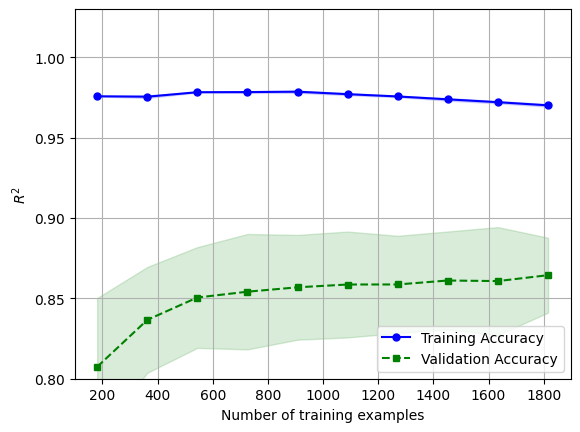

In [30]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

X_train = pipeline.fit_transform(X_train, y_train)
X_test = pipeline.transform(X_test)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, criterion='squared_error', n_jobs=-1, random_state=random_state)

lcurve_train_sizes, lcurve_train_scores, lcurve_valid_scores =\
        learning_curve(estimator=rf,
                X=X_train,
                y=y_train,
                train_sizes=np.linspace(0.1, 1.0, 10),
                cv=10,
                n_jobs=-1)

lcurve_train_mean = np.mean(lcurve_train_scores, axis=1)
lcurve_train_std = np.std(lcurve_train_scores, axis=1)
lcurve_valid_mean = np.mean(lcurve_valid_scores, axis=1)
lcurve_valid_std = np.std(lcurve_valid_scores, axis=1)

plt.plot(lcurve_train_sizes,
        lcurve_train_mean,
        color='blue', 
        marker='o', 
        markersize=5, 
        label='Training Accuracy')
plt.fill_between(lcurve_train_sizes,
                lcurve_train_mean + lcurve_train_std,
                lcurve_train_mean - lcurve_train_std,
                alpha=0.15,
                color='blue')
plt.plot(lcurve_train_sizes,
        lcurve_valid_mean,
        color='green',
        linestyle='--', 
        marker='s', 
        markersize=5, 
        label='Validation Accuracy')
plt.fill_between(lcurve_train_sizes,
                lcurve_valid_mean + lcurve_valid_std,
                lcurve_valid_mean - lcurve_valid_std,
                alpha=0.15,
                color='green')
plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel(r'$R^2$')
plt.legend(loc='lower right')
plt.ylim((0.8, 1.03))
plt.show()

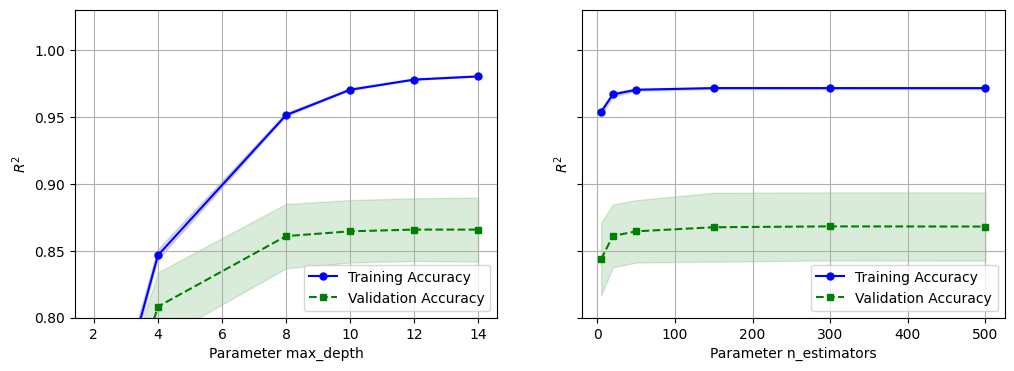

In [31]:
param_dict = {
    'max_depth': (2, 4, 8, 10, 12, 14),
    'n_estimators': (5, 20, 50, 150, 300, 500)
    }

fig, axs = plt.subplots(len(param_dict) // 2, 2, sharey=True, figsize=(12, 4))
axs = axs.flatten()

for i, (param_name, param_range) in enumerate(param_dict.items()):
        ax = axs[i]
        vcurve_train_scores, vcurve_valid_scores =\
                validation_curve(estimator=rf,
                        X=X_train,
                        y=y_train,
                        param_name=param_name,
                        param_range=param_range,
                        cv=10)


        vcurve_train_mean = np.mean(vcurve_train_scores, axis=1)
        vcurve_train_std = np.std(vcurve_train_scores, axis=1)
        vcurve_valid_mean = np.mean(vcurve_valid_scores, axis=1)
        vcurve_valid_std = np.std(vcurve_valid_scores, axis=1)

        ax.plot(param_range,
                vcurve_train_mean,
                color='blue', 
                marker='o', 
                markersize=5, 
                label='Training Accuracy')
        ax.fill_between(param_range,
                        vcurve_train_mean + vcurve_train_std,
                        vcurve_train_mean - vcurve_train_std,
                        alpha=0.15,
                        color='blue')
        ax.plot(param_range,
                vcurve_valid_mean,
                color='green',
                linestyle='--', 
                marker='s', 
                markersize=5, 
                label='Validation Accuracy')
        ax.fill_between(param_range,
                        vcurve_valid_mean + vcurve_valid_std,
                        vcurve_valid_mean - vcurve_valid_std,
                        alpha=0.15,
                        color='green')
        ax.grid()
        ax.set_xlabel(f'Parameter {param_name}')
        ax.set_ylabel(r'$R^2$')
        ax.legend(loc='lower right')
        ax.set_ylim((0.8, 1.03))

plt.show()

# Algorithm Selection through nested cross validation

In [32]:

from scipy.stats import randint

xgb_param_distributions = {
    "n_estimators": [100, 200, 500, 1000],                    # number of trees
    "max_depth": [3, 4, 5, 6, 7, 8, 10],                      # tree depth
    "learning_rate": [0.01, 0.02, 0.05, 0.1, 0.2, 0.3],      # step size shrinkage
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],                  # fraction of samples per tree
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],          # fraction of features per tree
    "min_child_weight": [1, 3, 5, 7, 10],                    # minimum sum of instance weight in a child
    "reg_alpha": [0, 0.01, 0.1, 1, 5, 10, 50],              # L1 regularization
    "reg_lambda": [0, 0.01, 0.1, 1, 5, 10, 50],             # L2 regularization
    "gamma": [0, 0.1, 0.5, 1, 2, 5],                         # minimum loss reduction to split
}

dtree_param_distributions = {
    "max_depth": randint(3, 20),                    # None is also possible, but RandomizedSearchCV prefers finite ranges
    "min_samples_split": randint(2, 20),           # minimum samples to split
    "min_samples_leaf": randint(1, 10),            # minimum samples in a leaf
    "max_features": ["sqrt", "log2", None],      # number of features to consider at each split
    "max_leaf_nodes": randint(10, 100),            # limit total leaves (optional)
}

from scipy.stats import uniform

elasticnet_param_distributions = {
    "alpha": uniform(1e-4, 10),              # regularization strength; e.g. roughly [1e-4, 10.01e-4)
    "l1_ratio": uniform(0.1, 0.8),          # mix between L1 and L2; e.g. roughly [0.1, 0.9)
    "max_iter": [1000, 2000, 5000],         # increase if convergence warnings appear
}

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet 
from sklearn.tree  import DecisionTreeRegressor
from xgboost import XGBRegressor

elastic_net = ElasticNet()
decision_tree = DecisionTreeRegressor()
xgboost = XGBRegressor(random_state=random_state)

elastic_net_rs = RandomizedSearchCV(
    estimator=elastic_net,
    param_distributions=elasticnet_param_distributions,
    refit=True,
    scoring='r2',
    n_iter=20,
    cv=2,
    random_state=random_state,
    n_jobs=-1
)

decision_tree_rs = RandomizedSearchCV(
    estimator=decision_tree,
    param_distributions=dtree_param_distributions,
    refit=True,
    scoring='r2',
    n_iter=20,
    cv=2,
    random_state=random_state,
    n_jobs=-1
)

xgboost_rs = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=xgb_param_distributions,
    refit=True,
    scoring='r2',
    n_iter=20,
    cv=2,
    random_state=random_state,
    n_jobs=-1
)

elastic_net_scores = cross_val_score(
    estimator=elastic_net_rs,
    X=X_train,
    y=y_train,
    scoring='r2',
    cv=5,
    n_jobs=-1)

decision_tree_scores = cross_val_score(
    estimator=decision_tree_rs,
    X=X_train,
    y=y_train,
    scoring='r2',
    cv=5,
    n_jobs=-1)

xgboost_scores = cross_val_score(
    estimator=xgboost_rs,
    X=X_train,
    y=y_train,
    scoring='r2',
    cv=5,
    n_jobs=-1)

print('Cross validation scores:')
print(f'\tElastic Net: {np.mean(elastic_net_scores):.3f}')
print(f'\tDecision Tree: {np.mean(decision_tree_scores):.3f}')
print(f'\tXGBoost: {np.mean(xgboost_scores):.3f}')


Cross validation scores:
	Elastic Net: 0.839
	Decision Tree: 0.783
	XGBoost: 0.877


# Model tuning

In [33]:
xgboost_rs = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=xgb_param_distributions,
    refit=True,
    scoring='r2',
    n_iter=20,
    cv=10,
    random_state=random_state,
    n_jobs=-1
)

xgboost_rs.fit(X_train, y_train)
print(f'Cross validation best score: {xgboost_rs.best_score_:.3f}')
print(f'Best parameters: {xgboost_rs.best_params_}')


Cross validation best score: 0.882
Best parameters: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}


In [34]:
train_score = xgboost_rs.score(X_train, y_train)
test_score = xgboost_rs.score(X_test, y_test)
print(f'Train score: {train_score:.3f}')
print(f'Test score: {test_score:.3f}')

Train score: 0.954
Test score: 0.914
